In [61]:
# imports
from os import system,path,listdir
from pathlib import Path
from collections import Counter
from gfagraphs import Graph
from matplotlib import pyplot as plt
from pandas import DataFrame
from statistics import mean, stdev

In [62]:
# variables
graph_paths:list[str] = [x for x in listdir('.') if x.endswith('.gfa')]
graph_ids:list[str] = [Path(x).stem for x in graph_paths]

In [63]:
# on charge les graphes en mémoire
graphs:list[Graph] = [Graph(x) for x in graph_paths]

In [64]:
print("Nom\tNœuds\tArêtes")
for x,g in enumerate(graphs):
    print(f"{graph_ids[x]}\t{len(g.segments)}\t{len(g.lines)}")

Nom	Nœuds	Arêtes
MC	34889	48130
PGGB	27213	37755


In [65]:
# calcul des valeurs de nœuds dans chemins
values:list[list[int]] = [[len(g.paths[p]['path']) for p in g.paths.keys()] for g in graphs]

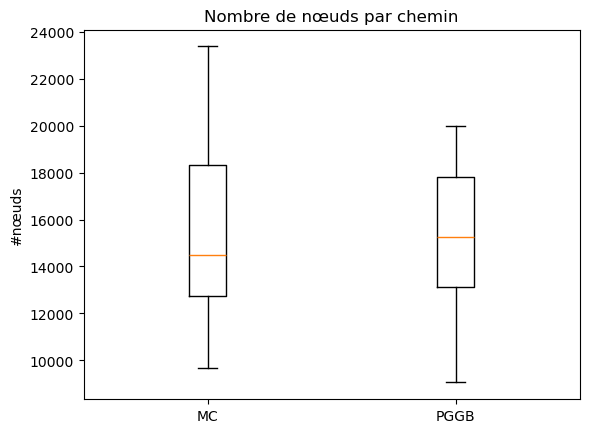

In [66]:
# visualisation des nœuds
plt.boxplot(values)
plt.title(f'Nombre de nœuds par chemin')
plt.xticks(ticks=range(1,len(graph_ids)+1),labels=graph_ids)
plt.ylabel('#nœuds')
plt.show()

In [67]:
print("Nom\tµ\tσ")
for x,g in enumerate(graphs):
    print(f"{graph_ids[x]}\t{mean(values[x])}\t{stdev(values[x])}")

Nom	µ	σ
MC	15576.333333333334	4359.405376664946
PGGB	15033.6	3219.2111456069483


In [68]:
values_unique:list[list[int]] = [[len(set([n for n,_ in g.paths[p]['path']]))/values[i][j] for j,p in enumerate(g.paths.keys())] for i,g in enumerate(graphs)]

In [69]:
print("Nom\tµ\tσ")
for x,g in enumerate(graphs):
    print(f"{graph_ids[x]}\t{mean(values_unique[x])}\t{stdev(values_unique[x])}")

Nom	µ	σ
MC	0.9647197509222483	0.08837197186115614
PGGB	0.889782058307531	0.07244549292512219


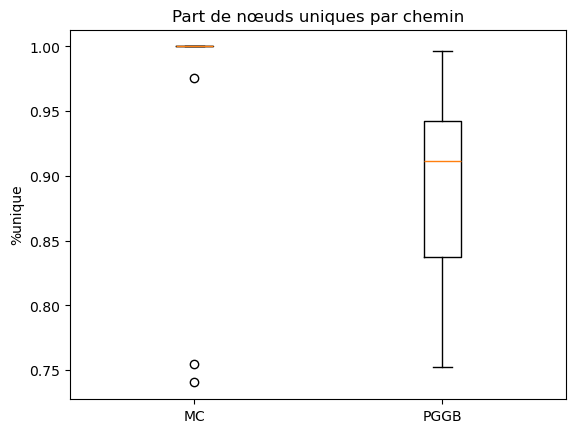

In [70]:
# visualisation des nœuds uniques par chemin
plt.boxplot(values_unique)
plt.title(f'Part de nœuds uniques par chemin')
plt.xticks(ticks=range(1,len(graph_ids)+1),labels=graph_ids)
plt.ylabel('%unique')
plt.show()